# CSE 144 Final Project | DINOv3
**Due: June 10, 2026**

This notebook trains DINOv3 (Meta, 2025) on the 100-class dataset using transfer learning, then generates a Kaggle submission using a 3-model ensemble with test-time augmentation.

## 1. Setup & Imports

In [1]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
from torchvision.transforms import v2 as T
from transformers import AutoModel
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Check CUDA (Colab/Linux GPU) first, then Apple MPS, then CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

# Change SEED to 46, 47 for the 2nd and 3rd ensemble runs
SEED = 48
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
print(f'Seed: {SEED}')

Using device: mps
Seed: 48


## 2. Data Loading & Augmentation

DINOv3 uses the same ImageNet normalization as EfficientNet (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]).

We apply data augmentation during training to help generalize with only ~10 images per class.

In [2]:
# ---- CHANGE THIS to wherever you unzipped the Kaggle dataset ----
DATA_DIR = './ucsc-cse-144-spring-2026-final-project'   # should contain train/ and test/ folders
# -----------------------------------------------------------------

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomGrayscale(p=0.1),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def make_dataset(transform):
    ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=transform)
    # ImageFolder sorts folders alphabetically ("10" before "2"), but Kaggle
    # requires label N for folder "N" — remap to numeric order.
    ds.class_to_idx = {cls: int(cls) for cls in ds.classes}
    ds.samples = [(path, int(ds.classes[lbl])) for path, lbl in ds.samples]
    ds.targets  = [int(ds.classes[lbl]) for lbl in ds.targets]
    return ds

# Determine split indices once with a fixed seed so val set is consistent across runs
_base = make_dataset(train_transform)
val_size   = int(0.1 * len(_base))
train_size = len(_base) - val_size
train_idx, val_idx = random_split(
    range(len(_base)), [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Create two SEPARATE dataset objects so setting val transform doesn't
# accidentally overwrite the training transform (they share no state)
train_dataset = Subset(make_dataset(train_transform), train_idx.indices)
val_dataset   = Subset(make_dataset(eval_transform),  val_idx.indices)

# num_workers=0 avoids a macOS multiprocessing deadlock with DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)

print(f'Total images: {len(_base)} | Train: {len(train_dataset)} | Val: {len(val_dataset)}')
print(f'Number of classes: {len(_base.classes)}')
print(f'Class mapping (first 5): {dict(list(_base.class_to_idx.items())[:5])}')
print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

Total images: 1079 | Train: 972 | Val: 107
Number of classes: 100
Class mapping (first 5): {'0': 0, '1': 1, '10': 10, '11': 11, '12': 12}
Train batches: 31, Val batches: 4


## 3. Build the Model

DINOv3 is a pure vision backbone — it has no built-in classification head.
We wrap it in a `DINOv3Classifier` that adds our own head on top.

Model used: `facebook/dinov3-vitb16-pretrain-lvd1689m` (ViT-B/16, trained on 1.7B images)

**Prerequisites:** `pip install transformers` and run `huggingface-cli login` with your HuggingFace token.

In [3]:
NUM_CLASSES = 100

class DINOv3Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = AutoModel.from_pretrained('facebook/dinov3-vitb16-pretrain-lvd1689m')
        self.head = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(self.backbone.config.hidden_size, num_classes)
        )

    def forward(self, x):
        # last_hidden_state[:, 0] is the CLS token — global image representation
        features = self.backbone(pixel_values=x).last_hidden_state[:, 0]
        return self.head(features)

model = DINOv3Classifier(NUM_CLASSES)

# Freeze backbone for Phase 1 — only the new head trains
for param in model.backbone.parameters():
    param.requires_grad = False

model = model.to(device)
print(f'Model ready. Backbone hidden size: {model.backbone.config.hidden_size}')
print(f'Head: {model.head}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Model ready. Backbone hidden size: 768
Head: Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=768, out_features=100, bias=True)
)
Trainable parameters: 76,900


## 4. Phase 1 — Train the Head Only

With the backbone frozen, only the new classification head trains.
We use 10 epochs here (more than EfficientNet) because DINOv3's backbone is larger
and the head needs more warmup before we unfreeze everything.

In [4]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total

criterion = nn.CrossEntropyLoss()

# Phase 1: only train the new head
optimizer_phase1 = optim.Adam(model.head.parameters(), lr=1e-3)

PHASE1_EPOCHS = 10
train_losses, val_losses, train_accs, val_accs = [], [], [], []

print('=== Phase 1: Training head only ===')
for epoch in range(PHASE1_EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer_phase1, criterion)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    train_losses.append(tr_loss); train_accs.append(tr_acc)
    val_losses.append(vl_loss);   val_accs.append(vl_acc)
    print(f'Epoch {epoch+1}/{PHASE1_EPOCHS} | Train Loss: {tr_loss:.3f} Acc: {tr_acc:.3f} | Val Loss: {vl_loss:.3f} Acc: {vl_acc:.3f}')

=== Phase 1: Training head only ===
Epoch 1/10 | Train Loss: 3.831 Acc: 0.231 | Val Loss: 2.706 Acc: 0.570
Epoch 2/10 | Train Loss: 1.922 Acc: 0.727 | Val Loss: 1.541 Acc: 0.701
Epoch 3/10 | Train Loss: 1.036 Acc: 0.858 | Val Loss: 1.072 Acc: 0.766
Epoch 4/10 | Train Loss: 0.688 Acc: 0.905 | Val Loss: 0.842 Acc: 0.766
Epoch 5/10 | Train Loss: 0.513 Acc: 0.917 | Val Loss: 0.734 Acc: 0.776
Epoch 6/10 | Train Loss: 0.421 Acc: 0.934 | Val Loss: 0.638 Acc: 0.794
Epoch 7/10 | Train Loss: 0.339 Acc: 0.949 | Val Loss: 0.589 Acc: 0.813
Epoch 8/10 | Train Loss: 0.290 Acc: 0.954 | Val Loss: 0.553 Acc: 0.794
Epoch 9/10 | Train Loss: 0.258 Acc: 0.963 | Val Loss: 0.543 Acc: 0.822
Epoch 10/10 | Train Loss: 0.225 Acc: 0.961 | Val Loss: 0.489 Acc: 0.813


## 5. Phase 2 — Fine-tune the Whole Network

Unfreeze all layers and fine-tune with a small learning rate and CutMix augmentation.
The cosine scheduler decays LR smoothly over all epochs.

In [5]:
# Unfreeze ALL layers for full fine-tuning
for param in model.parameters():
    param.requires_grad = True

print(f'Trainable parameters now: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

cutmix = T.CutMix(num_classes=NUM_CLASSES)

def train_one_epoch_cutmix(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = cutmix(images, labels)
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels.argmax(1)).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

PHASE2_EPOCHS = 25
optimizer_phase2 = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
# T_max matches PHASE2_EPOCHS for one smooth LR decay rather than cycling
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer_phase2, T_max=PHASE2_EPOCHS)

best_val_acc = 0.0

print('=== Phase 2: Fine-tuning full network with CutMix ===')
for epoch in range(PHASE2_EPOCHS):
    tr_loss, tr_acc = train_one_epoch_cutmix(model, train_loader, optimizer_phase2, criterion)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    scheduler.step()
    train_losses.append(tr_loss); train_accs.append(tr_acc)
    val_losses.append(vl_loss);   val_accs.append(vl_acc)
    print(f'Epoch {epoch+1}/{PHASE2_EPOCHS} | Train Loss: {tr_loss:.3f} Acc: {tr_acc:.3f} | Val Loss: {vl_loss:.3f} Acc: {vl_acc:.3f}')
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), f'dino_best_model_{SEED}.pth')
        print(f'  -> New best model saved! Val acc: {vl_acc:.3f}')

print(f'\nBest validation accuracy: {best_val_acc:.3f}')
print(f'Model saved as dino_best_model_{SEED}.pth')

Trainable parameters now: 85,737,316
=== Phase 2: Fine-tuning full network with CutMix ===
Epoch 1/25 | Train Loss: 1.823 Acc: 0.769 | Val Loss: 0.615 Acc: 0.813
  -> New best model saved! Val acc: 0.813
Epoch 2/25 | Train Loss: 1.763 Acc: 0.785 | Val Loss: 0.563 Acc: 0.804
Epoch 3/25 | Train Loss: 1.544 Acc: 0.843 | Val Loss: 0.488 Acc: 0.822
  -> New best model saved! Val acc: 0.822
Epoch 4/25 | Train Loss: 1.314 Acc: 0.830 | Val Loss: 0.478 Acc: 0.841
  -> New best model saved! Val acc: 0.841
Epoch 5/25 | Train Loss: 1.450 Acc: 0.813 | Val Loss: 0.474 Acc: 0.850
  -> New best model saved! Val acc: 0.850
Epoch 6/25 | Train Loss: 1.426 Acc: 0.775 | Val Loss: 0.500 Acc: 0.832
Epoch 7/25 | Train Loss: 1.338 Acc: 0.793 | Val Loss: 0.451 Acc: 0.841
Epoch 8/25 | Train Loss: 1.423 Acc: 0.761 | Val Loss: 0.428 Acc: 0.850
Epoch 9/25 | Train Loss: 1.355 Acc: 0.786 | Val Loss: 0.467 Acc: 0.813
Epoch 10/25 | Train Loss: 1.223 Acc: 0.791 | Val Loss: 0.450 Acc: 0.832
Epoch 11/25 | Train Loss: 1.14

## 6. Plot Training Curves

Include these plots in your report!

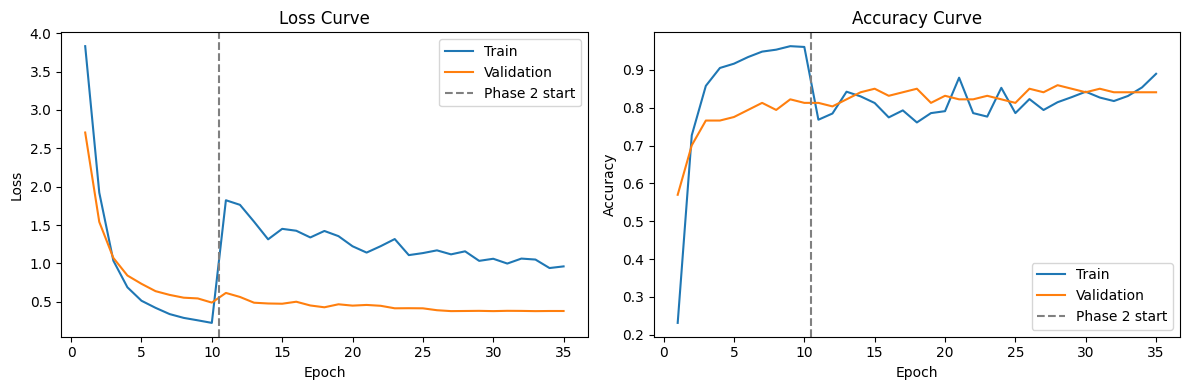

Saved dino_training_curves.png


In [6]:
total_epochs = PHASE1_EPOCHS + PHASE2_EPOCHS
epochs_range = range(1, total_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, train_losses, label='Train')
ax1.plot(epochs_range, val_losses,   label='Validation')
ax1.axvline(PHASE1_EPOCHS + 0.5, color='gray', linestyle='--', label='Phase 2 start')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss Curve'); ax1.legend()

ax2.plot(epochs_range, train_accs, label='Train')
ax2.plot(epochs_range, val_accs,   label='Validation')
ax2.axvline(PHASE1_EPOCHS + 0.5, color='gray', linestyle='--', label='Phase 2 start')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('Accuracy Curve'); ax2.legend()

plt.tight_layout()
plt.savefig('dino_training_curves.png', dpi=150)
plt.show()
print('Saved dino_training_curves.png')

## 7. Generate Kaggle Submission

Load all 3 ensemble models, run TTA on each test image, average predictions, write submission.csv.

In [ ]:
import torch.nn.functional as F

# All 3 ensemble model weights — run training 3 times (SEED=42,43,44) to generate these
MODEL_PATHS = ['dino_model_44.pth', 'dino_model_45.pth', 'dino_model_46.pth', 'dino_model_47.pth', 'dino_model_48.pth']
TTA_RUNS = 5  # augmented passes per image per model (plus 1 clean = 6 total)

test_dir = os.path.join(DATA_DIR, 'test')
test_files = sorted(os.listdir(test_dir), key=lambda x: int(x.split('.')[0]))

tta_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Accumulate averaged TTA probabilities across all ensemble models
all_probs = [None] * len(test_files)
for model_path in MODEL_PATHS:
    print(f'Running inference with {model_path}...')
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    with torch.no_grad():
        for i, fname in enumerate(test_files):
            img = Image.open(os.path.join(test_dir, fname)).convert('RGB')
            # 1 clean pass + TTA_RUNS augmented passes, averaged
            probs = F.softmax(model(eval_transform(img).unsqueeze(0).to(device)), dim=1)
            for _ in range(TTA_RUNS):
                probs += F.softmax(model(tta_transform(img).unsqueeze(0).to(device)), dim=1)
            probs /= (TTA_RUNS + 1)
            all_probs[i] = probs if all_probs[i] is None else all_probs[i] + probs

predictions = [p.argmax(1).item() for p in all_probs]

# IMPORTANT: Kaggle expects IDs as filenames (e.g. "0.jpg"), not integers
submission = pd.DataFrame({'ID': test_files, 'Label': predictions})
submission = submission.sort_values(by='ID', key=lambda x: x.map(lambda f: int(f.split('.')[0]))).reset_index(drop=True)
submission.to_csv('submission.csv', index=False)

print(f'Saved submission.csv with {len(submission)} predictions')
print(submission.head(10))

Running inference with dino_best_model_44.pth...
Running inference with dino_best_model_45.pth...
Running inference with dino_best_model_46.pth...
Running inference with dino_best_model_47.pth...
Running inference with dino_best_model_48.pth...
Saved submission.csv with 1036 predictions
      ID  Label
0  0.jpg     62
1  1.jpg     43
2  2.jpg     38
3  3.jpg     51
4  4.jpg     42
5  5.jpg     89
6  6.jpg      3
7  7.jpg     28
8  8.jpg     71
9  9.jpg     71


## 8. Save Model Weights for Google Drive

After all 3 training runs, upload `dino_best_model_42.pth`, `dino_best_model_43.pth`, and `dino_best_model_44.pth` to Google Drive and paste the link in your GitHub README.

In [ ]:
# Confirm the 3 ensemble model files exist before uploading to Google Drive
for seed in [44, 45, 46, 47, 48]:
    path = f'dino_model_{seed}.pth'
    exists = os.path.exists(path)
    print(f'{path}: {"✓ exists" if exists else "✗ MISSING — run training with SEED={seed}"}')

print('\nFiles to submit/upload:')
print('  submission.csv                         -> Kaggle')
print('  dino_model_42/43/44.pth                -> Google Drive (link in README)')
print('  dino_training_curves.png               -> include in report')
print('  this .ipynb file                       -> GitHub repo')

dino_best_model_44.pth: ✓ exists
dino_best_model_45.pth: ✓ exists
dino_best_model_46.pth: ✓ exists
dino_best_model_47.pth: ✓ exists
dino_best_model_48.pth: ✓ exists

Files to submit/upload:
  submission.csv                         -> Kaggle
  dino_best_model_42/43/44.pth           -> Google Drive (link in README)
  dino_training_curves.png               -> include in report
  this .ipynb file                       -> GitHub repo
